# 6. Cross-event stability of subject similarity in the minimal PC1-PC2 subspace

This notebook addresses Reviewer 1's question: *when we have the minimal-behavior
subspace for one event, the between-subject similarity in that space is defined; is
that similarity structure stable/comparable across the other critical events?*

**Design.** The study is within-subject across events: the same participants complete
all 10 events, so subject identity is matched across events and identity-matched
methods apply.

**Per-timepoint PCA caveat.** PCA is refit independently at each timepoint, so every
event's minimal-behavior plane (PC1-PC2 at the low-effective-dimensionality timepoint
`t*_e`, i.e. the peak of PC1+PC2 cumulative variance) has its *own* basis: the
eigenvector sign is arbitrary, near-equal eigenvalues can swap axis order, and the
plane may be rotated/reflected. Subject *coordinates* are therefore not directly
comparable across events. We compare **basis-free** objects instead:

- **Primary (RSA).** Per event, a subject x subject Euclidean distance matrix (RDM)
  `D_e[i,j] = ||s_i - s_j||_2`, which is invariant to any orthogonal transform
  (rotation / reflection / axis permutation). We then correlate the RDMs across events
  (second-order Spearman -> 10x10 matrix), test each pair with a Mantel permutation
  test (FDR-BH controlled), and summarise with a single stability index (mean
  off-diagonal second-order correlation) with a subject-bootstrap 95% CI.

**Scaling vs shape.** Raw PC-score distances retain the per-axis eigenvalue scaling
(the "scaling" the reviewer mentions); a whitened variant removes it (shape only).
**Condition.** PCA is always fit on the pooled sample (matching the paper); similarity
is computed pooled (primary) and within condition (robustness).

## Notation, abbreviations, and pipeline at a glance

**The question in one line.** Do the *same participants* keep the *same relative
positions* (and to the *same degree*) in the 2-D minimal-behaviour space across all 10
critical events?

**Pipeline at a glance.**
1. **Anchor** - find each event's minimal-dimensionality timepoint $t^*_e$ (Step 1).
2. **Scores** - project every subject into the PC1-PC2 plane at the timepoints around
   $t^*_e$, keeping the same matched subjects (Step 3).
3. **RDMs** - summarise each event by a basis-free subject x subject distance matrix,
   averaged over the window (Step 4).
4. **RSA** - correlate the RDMs across events, test each pair, and summarise with a
   single stability index + CI (Step 5).
5. **Report** - matrices, figures, and a draft results paragraph (Steps 7-9).

**How to interpret the headline number.** The stability index $S$ is the mean
second-order correlation across event pairs. $S \approx 1$ with significant Mantel tests
= the similarity structure is essentially identical across events; $S \approx 0$ = each
event has its own, unrelated structure. Intermediate $S$ with all pairs significant =
a **reliable but partial** shared structure plus an event-specific component.

**Abbreviations / symbols used throughout.**

| Symbol / term | Meaning |
|---|---|
| **PCA / PC** | principal component analysis / principal component |
| **ED** | effective dimensionality (how many dimensions the cloud truly uses) |
| $t^*_e$ | anchor timepoint of event $e$ = peak of PC1+PC2 variance (lowest ED) |
| $K$ (=2) | number of PCs spanning the minimal subspace (the PC1-PC2 plane) |
| $s^e_i(t)$ | subject $i$'s (PC1, PC2) coordinate in event $e$ at timepoint $t$ |
| **RDM** | representational dissimilarity matrix = subject x subject Euclidean distances |
| $\bar D^e$ | window-averaged RDM of event $e$ (one RDM per event) |
| **whitened / shape-only** | each PC divided by its SD before distances (removes scaling) |
| **RSA** | representational similarity analysis (here: correlating RDMs) |
| $\rho_{ef}$ | second-order Spearman correlation between RDMs of events $e$ and $f$ |
| $S$ | stability index = mean off-diagonal $\rho_{ef}$ over the 45 event pairs |
| **Mantel test** | permutation test for the correlation of two distance matrices |
| **FDR (BH)** | false discovery rate, Benjamini-Hochberg correction; reported as $q$ |
| **CI** | confidence interval (here 95%, subject bootstrap) |
| **MDS** | multidimensional scaling (2-D map of the events from $1-\rho$) |
| `common` | the matched subjects present in all 10 events (the analysis set) |

In [1]:
# Imports and configuration
import os
# Defensive: ensure matplotlib has a writable config/cache dir
os.environ.setdefault("MPLCONFIGDIR", os.path.join(os.getcwd(), ".mplconfig"))

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.spatial.distance import pdist, squareform
from scipy.stats import rankdata
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram

# --- Publication style ---
# PROJECT_ROOT = Path("/Users/johnmadrid/GitHub/pca-driving-behavior").resolve()

# 1) Load base style (despine, autolayout, etc.)
plt.style.use("seaborn-v0_8-ticks")
# # 2) Override with Nature-journal sizing / fonts so multi-panel figures don't overlap
# plt.rcParams.update({
#     "figure.figsize": (3.5, 2.625),
#     "figure.dpi": 100,
#     "figure.facecolor": "white",
#     "figure.constrained_layout.use": True,
#     "figure.autolayout": False,        # constrained_layout supersedes autolayout
#     "font.size": 7,
#     "font.family": "sans-serif",
#     "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
#     "axes.linewidth": 0.5,
#     "axes.labelsize": 8,
#     "axes.titlesize": 8,
#     "axes.prop_cycle": plt.cycler("color",
#         ["#E69F00", "#56B4E9", "#009E73", "#F0E442",
#          "#0072B2", "#D55E00", "#CC79A7"]),
#     "xtick.major.size": 2.5,
#     "xtick.major.width": 0.5,
#     "xtick.labelsize": 6,
#     "xtick.direction": "out",
#     "ytick.major.size": 2.5,
#     "ytick.major.width": 0.5,
#     "ytick.labelsize": 6,
#     "ytick.direction": "out",
#     "lines.linewidth": 1.2,
#     "lines.markersize": 3,
#     "lines.markeredgewidth": 0.4,
#     "legend.fontsize": 6,
#     "legend.frameon": False,
#     "savefig.dpi": 600,
#     "savefig.format": "pdf",
#     "savefig.bbox": "tight",
#     "savefig.pad_inches": 0.05,
#     "savefig.facecolor": "white",
#     "image.cmap": "viridis",
# })

# --- Paths (mirror the convention used in 5_discriminant_analysis.ipynb) ---
PROJECT_ROOT = Path("/Users/johnmadrid/GitHub/pca-driving-behavior").resolve()
CLEANED_CSV = PROJECT_ROOT / "results/cleaned_new/all_events/cleaned_event_all_events_timestamp_all_7_variables.csv"
VAR_CSV = PROJECT_ROOT / "results/variances/all_events/variances_event_all_events_timestamp_all_7_variables.csv"
OUT_DIR = PROJECT_ROOT / "results/subspace_stability"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Columns (names as stored in the cleaned CSV) ---
FEATURES = ["Eye Horizontal", "Eye Vertical", "Car Yaw",
            "Head Yaw", "Head Pitch", "Head Roll", "Steering"]
TIME_COL, COND_COL, EVENT_COL, UID_COL = "Time", "Condition", "Event", "uid"
COND_MAP = {0: "Automated", 1: "Manual"}

EVENTS = ["one", "two", "three", "four", "five", "six", "seven", "eight", "nine", "ten"]

# --- Analysis parameters ---
K = 2                 # number of PCs spanning the minimal subspace (PC1-PC2 plane)
WINDOW = 0.5          # +/- seconds around t*_e used for the window-averaged RDM (50 Hz -> ~25 frames)
N_PERM = 1000         # Mantel permutations per event pair (significance of the RDM correlation)
N_BOOT = 1000         # subject bootstrap resamples for the stability-index 95% CI
FDR_ALPHA = 0.05      # false-discovery-rate threshold (Benjamini-Hochberg) over the 45 event pairs
RANDOM_STATE = 42     # global seed for reproducibility (PCA SVD sign, permutations, bootstrap)

# Master switch for writing artefacts to disk: CSV matrices (Step 7), figure files
# (Step 8) and writeup.md (Step 9). Kept False so the notebook can be explored/inspected
# without overwriting committed outputs; set True to (re)generate the saved files.
SAVE_OUTPUTS = True

np.random.seed(RANDOM_STATE)
print("Project root:", PROJECT_ROOT)
print("Output dir   :", OUT_DIR)

Project root: /Users/johnmadrid/GitHub/pca-driving-behavior
Output dir   : /Users/johnmadrid/GitHub/pca-driving-behavior/results/subspace_stability


## Step 1 - Minimal-ED anchor `t*_e` per event

**What this step does.** For each event $e$ we pick one reference timepoint, the
*anchor* $t^*_e$, that defines that event's minimal-behaviour plane.

**Definition.** Let $r_k(t)$ be the fraction of variance explained by principal
component $k$ when PCA is fit across subjects at timepoint $t$. The anchor is the
timepoint that maximises the cumulative PC1+PC2 variance inside the event:

$$ t^*_e \;=\; \arg\max_{t \in \text{event } e} \big[\, r_1(t) + r_2(t) \,\big]. $$

**Why this timepoint.** *Effective dimensionality* (**ED**) measures how many
dimensions the cloud really uses; a common estimate is the participation ratio
$n_2(t) = \big(\sum_k \lambda_k\big)^2 / \sum_k \lambda_k^2$, where $\lambda_k$ are the
PCA eigenvalues. When variance concentrates in the first two PCs, $r_1+r_2$ is high and
ED is low. So the peak of $r_1+r_2$ is the **low-ED** moment at which behaviour is most
nearly 2-dimensional - the "minimal-behaviour subspace" the reviewer refers to.

**Implementation.** We reuse the `segment_event()` logic from
`3_variance_analysis.ipynb` (it locates the PC1 peak, then searches a +/-2 s neighbourhood
for the PC1+PC2 maximum). The output table lists $t^*_e$ and the corresponding
$r_1+r_2$ value for all 10 events.

*Abbreviations:* **PC** = principal component; **ED** = effective dimensionality;
$t^*_e$ = anchor (minimal-ED) timepoint of event $e$.

In [2]:
# Reuse segment_event() logic from 3_variance_analysis.ipynb to find t*_e (peak PC1+PC2)
variances_df = pd.read_csv(VAR_CSV)

def segment_event(df, event):
    largest = df[~df["Event"].str.contains("none|BE|AF")].groupby("Event")["PC1"].idxmax()
    mv = df[["PC1", "Time", "Event"]].loc[largest]
    pc1_max_ts = float(mv[mv["Event"] == event]["Time"].iloc[0])
    ed = df[df["Event"] == event]
    st, en = ed["Time"].min(), ed["Time"].max()
    seg = df.loc[(df["Time"] >= st - 1.5) & (df["Time"] <= en + 2)].copy()
    seg["PC1-2"] = seg["PC1"] + seg["PC2"]
    around = seg.loc[(seg["Time"] >= pc1_max_ts - 2) & (seg["Time"] <= pc1_max_ts + 2)]
    mx = around[around["PC1-2"] == around["PC1-2"].max()][["Time", "Event", "PC1-2"]]
    return float(mx["Time"].iloc[0]), float(mx["PC1-2"].iloc[0])

tstar, anchor_rows = {}, []
for ev in EVENTS:
    t_low, pc12 = segment_event(variances_df, ev)
    tstar[ev] = t_low
    anchor_rows.append({"Event": ev, "t_star": t_low, "PC1+PC2": round(pc12, 3)})
anchor_tbl = pd.DataFrame(anchor_rows)
print(anchor_tbl.to_string(index=False))

Event  t_star  PC1+PC2
  one   23.74    0.538
  two   70.18    0.553
three  138.64    0.572
 four  197.50    0.541
 five  237.00    0.516
  six  268.48    0.529
seven  333.66    0.517
eight  400.88    0.472
 nine  436.90    0.514
  ten  464.98    0.529


## Step 2 - Helper functions

These are the reusable building blocks for the rest of the notebook. Each is documented
inline in the next cell; in brief:

- `_compute_pca_scores` - reproduces the published pipeline (`StandardScaler` +
  `PCA(svd_solver="full", whiten=False)`, $k=2$) used in `2_pca.ipynb` /
  `5_discriminant_analysis.ipynb`. Returns the $N\times2$ subject scores in the PC1-PC2 plane.
- `_orthogonal_procrustes` - reflection-suppressed orthogonal aligner from
  `5_discriminant_analysis.ipynb` (finds the rotation $R$ best matching two configurations).
- `_vech` - vectorises the strict upper triangle of a square matrix (the unique entries).
- `_spearman` - Spearman correlation (Pearson on ranks), NaN-safe.
- `_cond` / `_rdm` - the **RDM** in condensed (vector) / square form (see Step 4 for the math).
- `mantel_test` - subject-permutation significance test for an RDM-vs-RDM correlation (Step 5).
- `fdr_bh` - Benjamini-Hochberg false-discovery-rate correction for multiple comparisons.

*Abbreviations:* **RDM** = representational dissimilarity matrix (here, subject x subject
Euclidean distances); **RSA** = representational similarity analysis;
**FDR** = false discovery rate.

In [3]:
# ---------------------------------------------------------------------------
# Reused / core helpers. Naming convention: a leading underscore marks a small
# internal utility. "cond" = condensed RDM (1-D vector of upper-triangle pairwise
# distances); "rdm" = the same as a full square matrix.
# ---------------------------------------------------------------------------

def _compute_pca_scores(X, n_components=K):
    """Published PCA pipeline: z-score each feature, then PCA -> first k scores.

    X            : (N_subjects x N_features) raw feature matrix at one timepoint.
    Returns      : (scores, pca, scaler) where scores is N x k (the PC1..PCk
                   coordinate of every subject in the minimal subspace).
    StandardScaler makes every feature contribute on a comparable scale (the
    paper's choice); whiten=False keeps the natural eigenvalue scaling of the PCs.
    """
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)                 # z-score features across subjects
    pca = PCA(n_components=n_components, svd_solver="full", whiten=False, random_state=RANDOM_STATE)
    scores = pca.fit_transform(Xs)               # subject coordinates in the PC plane
    return scores, pca, scaler

def _orthogonal_procrustes(A, B, allow_reflection=False):
    """Optimal orthogonal R (k x k) minimising ||A R - B||_F.

    Solved by the SVD of A^T B. If reflections are disallowed (det R < 0), we flip
    the last singular vector to force a pure rotation (det R = +1).
    """
    S = A.T @ B
    U, _, Vt = np.linalg.svd(S)
    R = U @ Vt
    if not allow_reflection and np.linalg.det(R) < 0:
        U[:, -1] *= -1.0                          # suppress reflection -> proper rotation
        R = U @ Vt
    return R

def _vech(D):
    """Strict upper triangle of a square matrix as a 1-D vector (its unique entries)."""
    iu = np.triu_indices_from(D, k=1)
    return D[iu]

def _spearman(a, b):
    """Spearman correlation = Pearson correlation on ranks; NaN-safe (needs >=3 valid pairs)."""
    a = np.asarray(a, float); b = np.asarray(b, float)
    m = ~(np.isnan(a) | np.isnan(b))             # drop pairs where either entry is NaN
    if m.sum() < 3:
        return np.nan
    return float(np.corrcoef(rankdata(a[m]), rankdata(b[m]))[0, 1])

def _cond(S, whiten=False):
    """Condensed RDM: upper-triangle pairwise Euclidean distances of the rows of S.

    S      : (N_subjects x k) score matrix. Output length is N*(N-1)/2.
    whiten : if True, divide each PC column by its SD first ("shape-only" distances,
             removing the eigenvalue scaling so PC1 and PC2 weigh equally).
    A subject with any NaN score produces NaN distances (handled downstream by nanmean).
    """
    S = np.asarray(S, float)
    if whiten:
        sd = np.nanstd(S, axis=0, ddof=1)
        sd[~np.isfinite(sd) | (sd == 0)] = 1.0   # guard against zero/NaN SD
        S = S / sd
    return pdist(S, metric="euclidean")

def _rdm(S, whiten=False):
    """Square (N x N) version of the RDM from `_cond` (zeros on the diagonal)."""
    return squareform(_cond(S, whiten=whiten))

def procrustes_disparity(A, B):
    """Reflection-suppressed Procrustes disparity between two configurations.

    Both clouds are centred and scaled to unit Frobenius norm, then B is matched by
    rotating A. Disparity = residual sum of squares ||A R - B||^2, on a 0 (identical)
    to 2 (unrelated) scale. Lower = more similar.
    """
    A0 = A - A.mean(0); B0 = B - B.mean(0)        # centre
    nA = np.linalg.norm(A0); nB = np.linalg.norm(B0)
    A0 = A0 / nA; B0 = B0 / nB                    # scale to unit size (size-invariant)
    R = _orthogonal_procrustes(A0, B0, allow_reflection=False)
    return float(np.sum((A0 @ R - B0) ** 2))

def rv_coefficient(A, B):
    """RV coefficient between two configurations (0 = unrelated, 1 = identical).

    Compares the subject x subject Gram (inner-product) matrices Sa, Sb; it is the
    multivariate analogue of a squared correlation and is invariant to rotation/scale.
    """
    A0 = A - A.mean(0); B0 = B - B.mean(0)
    Sa = A0 @ A0.T; Sb = B0 @ B0.T               # Gram matrices of the two clouds
    denom = np.sqrt(np.trace(Sa @ Sa) * np.trace(Sb @ Sb))
    return float(np.trace(Sa @ Sb) / denom) if denom > 0 else np.nan

def mantel_test(cond_e, cond_f, n_perm=N_PERM, rng=None):
    """One-sided (positive) Mantel test for the correlation between two RDMs.

    Inputs are condensed RDMs over the *same* subjects. Significance comes from
    permuting subject labels of one RDM and recomputing the correlation; the p-value
    is the fraction of permutations reaching the observed correlation. Implementation
    notes: ranks are precomputed (so the rank correlation is a Pearson r on rank
    vectors), and a permutation simply relabels rows/columns of the rank matrix RD,
    which keeps the dependence structure intact (the reason a plain shuffle is invalid).
    """
    rng = np.random.default_rng(RANDOM_STATE) if rng is None else rng
    n = int(round((1 + np.sqrt(1 + 8 * cond_e.size)) / 2))   # recover #subjects from vector length
    iu = np.triu_indices(n, k=1)
    rank_e = rankdata(cond_e)
    rank_f = rankdata(cond_f)
    RD = np.zeros((n, n)); RD[iu] = rank_e; RD = RD + RD.T    # symmetric rank matrix of RDM_e
    fc = rank_f - rank_f.mean(); fden = np.sqrt(fc @ fc)      # precompute the f-side for speed
    def pear_with_f(a):
        ac = a - a.mean()
        return float(ac @ fc / (np.sqrt(ac @ ac) * fden))
    r_obs = pear_with_f(rank_e)                              # observed rank (Spearman) correlation
    cnt = 0
    for _ in range(n_perm):
        p = rng.permutation(n)                              # permute the subject labels
        if pear_with_f(RD[np.ix_(p, p)][iu]) >= r_obs:
            cnt += 1
    return r_obs, (1 + cnt) / (1 + n_perm)                  # +1/+1: never report p = 0

def fdr_bh(pvals):
    """Benjamini-Hochberg FDR-adjusted q-values for a vector of p-values."""
    p = np.asarray(pvals, float)
    n = p.size
    order = np.argsort(p)
    ranked = p[order]
    q = ranked * n / (np.arange(n) + 1)                     # p_(i) * n / i
    q = np.minimum.accumulate(q[::-1])[::-1]                # enforce monotonic q
    out = np.empty_like(q); out[order] = np.clip(q, 0, 1)
    return out

## Step 3 - Reconstruct matched subject scores at `t*_e` (+/- window)

**What this step does.** It turns raw behaviour into a PC1-PC2 coordinate for every
subject, at every timepoint inside each event's window, ready for the distance matrices
of Step 4.

**Procedure.** We read only the rows of the (large) cleaned CSV that fall in each
event's window $[\,t^*_e - W,\; t^*_e + W\,]$ (with $W=$ `WINDOW`). Then, **independently
at each timepoint $t$**, we fit the published PCA pipeline across subjects and keep the
first two scores:

$$ s^{e}_i(t) \;=\; \big(\text{PC1}_i(t),\, \text{PC2}_i(t)\big) \in \mathbb{R}^2 . $$

Each subject keeps their `uid` and `Condition` label so the analysis stays
**identity-matched**.

**Matched analysis set.** Conditions are between-subjects and a few subjects are missing
from some events, so we restrict every comparison to the **common set of subjects
present at every event's anchor timepoint** (`common`; here 283 of 284). This guarantees
the RDMs of different events index exactly the same people, which is what makes them
comparable.

**Inspection objects produced here.**
- `win_df` - dict `event -> DataFrame` of the raw windowed rows (one row per
  subject x timepoint).
- `full_window_df` - the same data concatenated into **one** tidy DataFrame across all
  events (added below for easy filtering/inspection).
- `scores_by_t` - nested dict `event -> timepoint -> (uid-indexed PC1/PC2/Condition)`.
- `scores_long` - the PC scores flattened into **one** tidy DataFrame
  `[Event, Time, uid, PC1, PC2, Condition]` (added in the next step's code).

**Sanity checks** confirm (i) the PCA reconstruction $X_s \cdot \text{loadings} =
\text{scores}$ and (ii) that the RDM is unchanged when the plane is rotated/reflected -
the invariance our whole approach relies on.

In [4]:
# Windowed load of cleaned scores
usecols = FEATURES + [COND_COL, TIME_COL, EVENT_COL, UID_COL]
keep = {ev: [] for ev in EVENTS}
for chunk in pd.read_csv(CLEANED_CSV, usecols=usecols, chunksize=1_000_000):
    sub = chunk[chunk[EVENT_COL].isin(EVENTS)]
    if sub.empty:
        continue
    for ev in EVENTS:
        lo, hi = tstar[ev] - WINDOW - 1e-9, tstar[ev] + WINDOW + 1e-9
        g = sub[(sub[EVENT_COL] == ev) & (sub[TIME_COL] >= lo) & (sub[TIME_COL] <= hi)]
        if len(g):
            keep[ev].append(g)
win_df = {ev: pd.concat(v, ignore_index=True) for ev, v in keep.items()}
for ev in EVENTS:
    d = win_df[ev]
    print(f"event {ev:5s}: rows={len(d):5d}  timepoints={d[TIME_COL].nunique():3d}  uids={d[UID_COL].nunique()}")

# Single concatenated view of all events' windowed rows (easy to filter/inspect).
# Equivalent content to win_df, but one DataFrame: e.g. full_window_df.query("Event == 'one'").
full_window_df = pd.concat(win_df.values(), ignore_index=True)
print(f"\nfull_window_df: {full_window_df.shape[0]} rows x {full_window_df.shape[1]} cols "
      f"({full_window_df[EVENT_COL].nunique()} events)")

event one  : rows=14484  timepoints= 51  uids=284
event two  : rows=14484  timepoints= 51  uids=284
event three: rows=14484  timepoints= 51  uids=284
event four : rows=14484  timepoints= 51  uids=284
event five : rows=14484  timepoints= 51  uids=284
event six  : rows=14484  timepoints= 51  uids=284
event seven: rows=14484  timepoints= 51  uids=284
event eight: rows=14484  timepoints= 51  uids=284
event nine : rows=14484  timepoints= 51  uids=284
event ten  : rows=12452  timepoints= 44  uids=283

full_window_df: 142808 rows x 11 cols (10 events)


In [5]:
# inspect the PC scores for a single event at t*_e (high ED timepoint)
full_window_df.query("Event == 'one'")

,Eye Horizontal,Eye Vertical,Car Yaw,Head Yaw,Head Pitch,Head Roll,Steering,Condition,Time,Event,uid
0,1.808875,-2.925002,46.892856,-21.445207,3.647819,6.229961,-0.962200,0,23.24,one,017397ca31114170abc2ff61a217460b
1,12.891671,13.113016,46.920730,-4.072231,7.092758,-5.445549,-0.962200,0,23.24,one,02652779cbca4679bd48ebc0a0b7af77
2,12.066485,9.884752,46.859275,-2.876551,4.681891,-5.510771,-0.498369,0,23.24,one,04df3843fbf741579f77e534dacb7b9d
3,10.275888,8.910660,46.879654,-0.275938,6.570930,-2.485777,0.155309,0,23.24,one,071f070f66104d899c2c01daccd48165
4,17.828483,2.277087,46.918135,-6.363794,0.156081,-2.239212,-0.447610,0,23.24,one,0741fd89e71d4669a8b2cd52d0e4a4ef
...,...,...,...,...,...,...,...,...,...,...,...
14479,5.709109,-4.872431,41.014229,-19.858959,-5.339056,2.768744,-0.155309,1,24.24,one,fabaea7e1d0347068ab78874b4445648
14480,20.454664,-7.147217,41.267253,-3.918364,-11.413206,0.312922,-1.214244,1,24.24,one,fe568108ba4742cb974bb62748627b05
14481,16.895112,0.061218,45.954296,-6.192148,-3.409419,-1.867343,-4.319285,1,24.24,one,ff3710a0ba6245d6be18e2925a4a373e
14482,-6.684224,-11.228816,44.758379,-5.764838,-4.542530,4.722744,-0.101050,1,24.24,one,ffb7f9e65f664c1fab6591d9b2afc085


In [6]:
# Per-event, per-timepoint PCA scores (k=2), indexed by uid
def event_timepoint_scores(df_ev):
    """For one event, fit PCA separately at each timepoint and return a dict
    {timepoint -> uid-indexed DataFrame[PC1..PCk, Condition]}."""
    out = {}
    for t, g in df_ev.groupby(TIME_COL):                  # one PCA per timepoint
        g = g.dropna(subset=FEATURES)                     # drop subjects with missing features
        if g[UID_COL].duplicated().any():
            g = g.drop_duplicates(subset=UID_COL, keep="first")
        X = g[FEATURES].to_numpy(float)
        if X.shape[0] < 3:                                # need >=3 subjects for a stable PCA
            continue
        scores, pca, scaler = _compute_pca_scores(X, K)   # subject coordinates in the PC plane
        sdf = pd.DataFrame(scores, columns=[f"PC{i+1}" for i in range(K)])
        sdf[UID_COL] = g[UID_COL].to_numpy()
        sdf[COND_COL] = g[COND_COL].to_numpy()
        out[round(float(t), 3)] = sdf.set_index(UID_COL)  # index by subject id for easy alignment
    return out

scores_by_t = {ev: event_timepoint_scores(win_df[ev]) for ev in EVENTS}

# Center timepoint key (closest available timepoint to t*_e) per event
center_t = {ev: min(scores_by_t[ev], key=lambda tt: abs(tt - tstar[ev])) for ev in EVENTS}

# Matched (common) subject set: present at every event's center timepoint
center_uids = {ev: set(scores_by_t[ev][center_t[ev]].index) for ev in EVENTS}
common = sorted(set.intersection(*center_uids.values()))
print("Common matched subjects across all 10 events:", len(common))

# Condition lookup over common subjects (condition is between-subjects)
cond_lookup = {}
for ev in EVENTS:
    s = scores_by_t[ev][center_t[ev]]
    for u in s.index:
        cond_lookup[u] = int(s.loc[u, COND_COL])
common_auto = [u for u in common if cond_lookup[u] == 0]
common_manual = [u for u in common if cond_lookup[u] == 1]
print(f"  Automated (0): {len(common_auto)}   Manual (1): {len(common_manual)}")

# Tidy ("long") view of all PC scores in one DataFrame: one row per (event, timepoint, subject).
# Flattens the nested scores_by_t dict so it is easy to filter/inspect, e.g.:
#   scores_long.query("Event == 'one' and Time == @center_t['one']")
_long = []
for ev in EVENTS:
    for t, sdf in scores_by_t[ev].items():
        tmp = sdf.reset_index()                 # bring uid back as a column
        tmp.insert(0, "Event", ev)
        tmp.insert(1, TIME_COL, t)
        _long.append(tmp)
scores_long = pd.concat(_long, ignore_index=True)
scores_long[COND_COL] = scores_long[COND_COL].map(COND_MAP)   # 0/1 -> Automated/Manual label
scores_long = scores_long[["Event", TIME_COL, UID_COL] + [f"PC{i+1}" for i in range(K)] + [COND_COL]]
print(f"scores_long: {scores_long.shape[0]} rows x {scores_long.shape[1]} cols "
      f"(events x timepoints x subjects)")

Common matched subjects across all 10 events: 283
  Automated (0): 152   Manual (1): 131
scores_long: 142808 rows x 6 cols (events x timepoints x subjects)


In [7]:
# inspect the PC scores for a single event at t*_e (high ED timepoint)
scores_long.query("Event == 'one' and Time == @center_t['one']")

,Event,Time,uid,PC1,PC2,Condition
7100,one,23.74,017397ca31114170abc2ff61a217460b,0.740734,-0.322573,Automated
7101,one,23.74,02652779cbca4679bd48ebc0a0b7af77,-2.468720,-0.332261,Automated
7102,one,23.74,04df3843fbf741579f77e534dacb7b9d,-1.964866,-0.250687,Automated
7103,one,23.74,071f070f66104d899c2c01daccd48165,-1.636198,-0.227415,Automated
7104,one,23.74,0741fd89e71d4669a8b2cd52d0e4a4ef,-0.746335,-0.546054,Automated
...,...,...,...,...,...,...
7379,one,23.74,fabaea7e1d0347068ab78874b4445648,1.314387,1.444618,Manual
7380,one,23.74,fe568108ba4742cb974bb62748627b05,2.469398,1.453510,Manual
7381,one,23.74,ff3710a0ba6245d6be18e2925a4a373e,-0.312878,-1.788313,Manual
7382,one,23.74,ffb7f9e65f664c1fab6591d9b2afc085,1.675139,-0.895223,Manual


In [8]:
# inspect the PC scores for a single subject in a single event around t*_e (high ED timepoint)
scores_long.query("Event == 'one' and uid == '017397ca31114170abc2ff61a217460b'")

,Event,Time,uid,PC1,PC2,Condition
0,one,23.24,017397ca31114170abc2ff61a217460b,-0.847994,-0.395522,Automated
284,one,23.26,017397ca31114170abc2ff61a217460b,0.813057,-0.366624,Automated
568,one,23.28,017397ca31114170abc2ff61a217460b,0.796217,-0.307425,Automated
852,one,23.30,017397ca31114170abc2ff61a217460b,0.842778,-0.129231,Automated
1136,one,23.32,017397ca31114170abc2ff61a217460b,0.793038,-0.124072,Automated
1420,one,23.34,017397ca31114170abc2ff61a217460b,0.695699,-0.068952,Automated
1704,one,23.36,017397ca31114170abc2ff61a217460b,0.713815,0.163215,Automated
1988,one,23.38,017397ca31114170abc2ff61a217460b,0.716596,0.439796,Automated
2272,one,23.40,017397ca31114170abc2ff61a217460b,0.746690,0.580506,Automated
2556,one,23.42,017397ca31114170abc2ff61a217460b,0.728191,0.572084,Automated


## Sanity checks 
**Check 1: are scores just the standardized data projected?**
- **What it checks:** that the PCA scores returned by scikit‑learn are really just the standardized data projected onto the loading vectors — i.e., scores = StandardScaler(X) @ components.T. This is the definition of a PCA projection.

- **Why it matters here:** the notebook later reconstructs and reasons about subject coordinates and distances in the PC plane. This confirms the score matrix it's using is exactly that linear projection, with no hidden centering, whitening, or sign trick that would break the reasoning.
Result 5.33e-15: essentially zero (floating‑point round‑off, ~machine epsilon).
- **When it would be bad/suspicious:**
A value like 1e-3, 0.1, or larger means the score matrix is not a plain projection of the standardized data. Likely causes: whiten=True got turned on (scores divided by singular values), the scaler used for the check differs from the one used to fit PCA, mismatched/misaligned rows, or components_ orientation got transposed wrong.
Any of those would invalidate the "subject coordinates in the PC1–PC2 plane" interpretation downstream.

**Check 2 — RDM invariance to an orthogonal transform Q**
- **What it checks:** that rotating/reflecting the PC plane by a random orthogonal matrix Q leaves the subject×subject Euclidean distance matrix (RDM) unchanged. Mathematically ‖Qx − Qy‖ = ‖x − y‖, so distances are invariant to any rotation/reflection/axis‑swap.

- **Why it matters here:** this is the central justification for the entire approach. Because PCA is refit independently at each event's t*, each event's PC basis has an arbitrary sign, axis order, and rotation, so raw coordinates aren't comparable across events. The notebook gets around that by comparing RDMs instead of coordinates. This check empirically confirms the RDM really is basis‑free, so the cross‑event RSA comparisons are legitimate and not contaminated by the arbitrary PCA orientation.

**Check 3 — RDM is symmetric, zero‑diagonal, correct shape**
**What it checks:** that the RDM is a well‑formed distance matrix:
- symmetric — distance(i,j) = distance(j,i)
- zero diagonal — every subject has zero distance to itself
- shape (283, 283) — one row/column per matched subject
**Why it matters here:** these are the formal properties a distance matrix must have for the downstream tools (Spearman over the upper triangle, Mantel permutation tests, MDS, linkage) to be valid.

In [9]:
# Sanity checks: reconstruction identity and orthogonal-transform invariance of the RDM
ev0, t0 = "one", center_t["one"]
g0 = win_df["one"][np.isclose(win_df["one"][TIME_COL], t0)].dropna(subset=FEATURES).drop_duplicates(UID_COL)
X0 = g0[FEATURES].to_numpy(float)
scores0, pca0, scaler0 = _compute_pca_scores(X0, K)
recon = float(np.max(np.abs(scaler0.transform(X0) @ pca0.components_.T - scores0)))
print(f"[check] Xs @ loadings ~= scores : max|diff| = {recon:.2e}")

S_demo = scores_by_t["one"][t0].reindex(common)[["PC1", "PC2"]].to_numpy(float)
D_demo = _rdm(S_demo)
rng_chk = np.random.default_rng(0)
Q, _ = np.linalg.qr(rng_chk.standard_normal((2, 2)))          # random orthogonal 2x2
D_rot = _rdm(S_demo @ Q)
print(f"[check] RDM invariance to orthogonal Q : max|diff| = {np.nanmax(np.abs(D_demo - D_rot)):.2e}")
print(f"[check] RDM symmetric={np.allclose(D_demo, D_demo.T, equal_nan=True)}, "
      f"zero diagonal={np.allclose(np.diag(D_demo), 0)}, shape={D_demo.shape}")

[check] Xs @ loadings ~= scores : max|diff| = 5.33e-15
[check] RDM invariance to orthogonal Q : max|diff| = 3.55e-15
[check] RDM symmetric=True, zero diagonal=True, shape=(283, 283)


## Step 4 - Window-averaged RDMs (raw and shape-only)

**What is an RDM?** A *representational dissimilarity matrix* summarises an event purely
by **how far apart subjects are from each other** in the PC1-PC2 plane. For event $e$ at
timepoint $t$ it is the subject x subject matrix of Euclidean distances:

$$ D^{e}_{t}[i,j] \;=\; \big\lVert s^{e}_i(t) - s^{e}_j(t) \big\rVert_2 . $$

It is symmetric with a zero diagonal, so all of its information lives in the
$N(N-1)/2$ upper-triangle entries (the *condensed* form `_cond` returns).

**Why an RDM?** Distances between subjects depend only on the *relative geometry* of the
cloud, so $D^e_t$ is **invariant to any orthogonal transform** of the plane (sign flip,
axis swap, rotation, reflection). This is exactly the per-timepoint PCA ambiguity from
Step 1, so the RDM removes the one thing that is not comparable across events while
keeping the "who-is-similar-to-whom" structure we care about.

**What is a window-averaged RDM?** A single timepoint is noisy, so for each event we
average the per-timepoint RDMs over its window $W = \{t : |t-t^*_e|\le W\}$:

$$ \bar{D}^{e} \;=\; \frac{1}{|W|}\sum_{t \in W} D^{e}_{t}. $$

Averaging is legitimate because **every** $D^e_t$ is already basis-free, so they live on
a common scale and never need re-aligning. $\bar D^e$ is the one RDM that represents
event $e$ in all later steps.

**Variants computed here** (each is a $\bar D^e$ per event):
- `raw_pooled` - raw distances, all `common` subjects (keeps the PC1/PC2 eigenvalue
  *scaling* the reviewer mentions).
- `shape_pooled` - whitened distances (each PC divided by its SD): *shape only*, scaling
  removed.
- `raw_auto`, `raw_manual` - raw distances computed within the Automated / Manual
  subjects (robustness to driving mode).

For storage efficiency the RDMs are kept in **condensed (vector) form**; the next code
cell adds `rdm_square(variant, event)` to view any of them as a labelled
`uid x uid` matrix.

In [10]:
# Window-averaged RDM per event over a chosen subject set (condensed upper-triangle form)
def window_cond(ev, subjects, whiten=False):
    """Average the per-timepoint condensed RDMs over the event's window -> one RDM_e.
    `subjects` fixes a common row/column order so RDMs are aligned across events."""
    mats = [_cond(scores_by_t[ev][t].reindex(subjects)[["PC1", "PC2"]].to_numpy(float), whiten)
            for t in scores_by_t[ev]]                  # one condensed RDM per timepoint
    return np.nanmean(np.stack(mats, axis=0), axis=0)  # window average (basis-free, so valid)

# Each variant = (which subjects, raw vs whitened distances). See the markdown above.
variants = {
    "raw_pooled":   dict(subjects=common,        whiten=False),   # scaling-preserving, all subjects
    "shape_pooled": dict(subjects=common,        whiten=True),    # shape-only (whitened)
    "raw_auto":     dict(subjects=common_auto,   whiten=False),   # within Automated
    "raw_manual":   dict(subjects=common_manual, whiten=False),   # within Manual
}

# rdms[name][event] is the condensed RDM (length n*(n-1)/2) over that variant's subjects
rdms = {name: {ev: window_cond(ev, cfg["subjects"], cfg["whiten"]) for ev in EVENTS}
        for name, cfg in variants.items()}
for name, cfg in variants.items():
    ns = len(cfg["subjects"]); P = rdms[name]["one"].size
    print(f"variant {name:13s}: {ns} subjects, 10 event RDMs ({P} unique subject pairs each)")

def rdm_square(name, event):
    """Inspection helper: return a window-averaged RDM as a labelled uid x uid DataFrame
    (symmetric, zero diagonal). Example: rdm_square('raw_pooled', 'one').iloc[:5, :5]."""
    subjects = variants[name]["subjects"]
    M = squareform(rdms[name][event])               # condensed vector -> full square matrix
    return pd.DataFrame(M, index=subjects, columns=subjects)

# Example: top-left 5x5 corner of the primary RDM for event 'one'
print("\nrdm_square('raw_pooled', 'one') - top-left 5x5 corner (subject-subject distances):")
print(rdm_square("raw_pooled", "one").iloc[:5, :5].round(3).to_string())

variant raw_pooled   : 283 subjects, 10 event RDMs (39903 unique subject pairs each)
variant shape_pooled : 283 subjects, 10 event RDMs (39903 unique subject pairs each)
variant raw_auto     : 152 subjects, 10 event RDMs (11476 unique subject pairs each)
variant raw_manual   : 131 subjects, 10 event RDMs (8515 unique subject pairs each)

rdm_square('raw_pooled', 'one') - top-left 5x5 corner (subject-subject distances):
                                  017397ca31114170abc2ff61a217460b  01834492f844419681793c107d49ed71  01a81ed75f3548249a0b378943e39f6b  020e858f532e458d88749fa3191fc8cb  02652779cbca4679bd48ebc0a0b7af77
017397ca31114170abc2ff61a217460b                             0.000                             4.349                             0.882                             1.357                             3.326
01834492f844419681793c107d49ed71                             4.349                             0.000                             3.753                             3.091   

variant='raw_pooled'  event='one'  subjects=283  pairs=39903  window timepoints=51
  window-mean distance : median=2.181  range=[0.072, 9.177]
  within-window CV     : median=0.179  range=[0.009, 1.563]  (higher CV = that pair's distance is less stable across the window)
Figure saved as rdm_raw_pooled_one.pdf


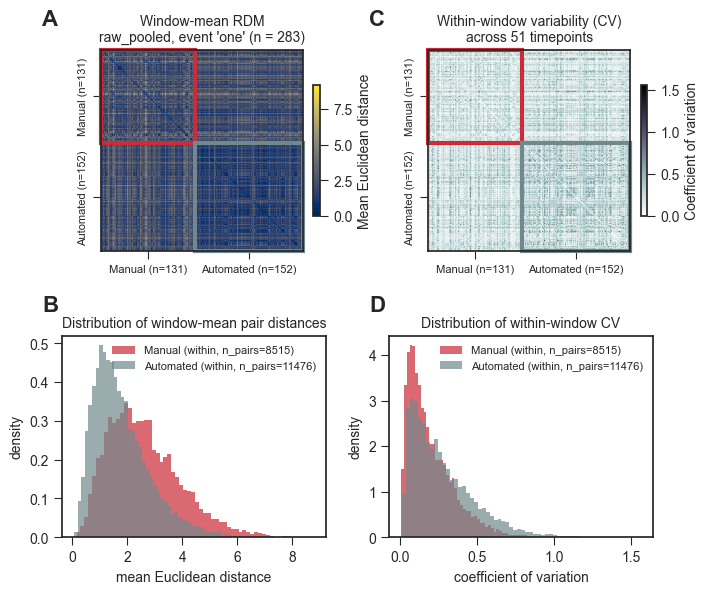


Window-MEAN distances - top-left 9x9 corner (uid x uid):
                                  01834492f844419681793c107d49ed71  01a81ed75f3548249a0b378943e39f6b  020e858f532e458d88749fa3191fc8cb  0453fb147e8345ecaf27e33d6809e083  047a12f642df42719fa79efc2854f943  0597f8c487be412d924d1c9c706b8b22  070776e658804091ae40326a170f05af  085598b4f7a1475b87dd4a58435d5064  0ae161af3c3b466a91f9670a3ffa2b1c
01834492f844419681793c107d49ed71                             0.000                             3.753                             3.091                             5.378                             2.868                             3.811                             4.735                             5.341                             4.235
01a81ed75f3548249a0b378943e39f6b                             3.753                             0.000                             0.965                             2.095                             1.824                             1.323                            

In [11]:
# --- Inspect one event's window-averaged RDM and its within-window variability ---
# For a chosen (variant, event) this shows (a) the window-MEAN subject-subject distances and
# (b) the per-pair coefficient of variation CV = std/mean across the window's timepoints, i.e.
# how much each subject-pair distance wobbles over +/-WINDOW. Output: 2 heatmaps + 2 histograms
# + a numeric k x k corner. Change `variant` to 'raw_pooled' / 'raw_auto' / 'raw_manual'.

def visualize_rdm(variant="raw_pooled", event="one", k=8, ddof=1, cmap="cividis",
                  group_by_condition=True, cond_order=(1, 0), fig_name=None):
    # New colors
    automated_color = "#cc2936"
    manual_color = "#71898E"

    if variant not in variants:
        raise ValueError(f"variant must be one of {list(variants)}")
    if event not in EVENTS:
        raise ValueError(f"event must be one of {EVENTS}")
    subjects = variants[variant]["subjects"]
    whiten = variants[variant]["whiten"]

    # Group subjects by driving condition so each condition is a contiguous block in the
    # matrix. cond_order=(1, 0) -> Manual on top/left, Automated on bottom/right.
    # `blocks` = [(label, start_index, size), ...] used to outline the diagonal blocks.
    blocks = None
    block_colors = None
    if group_by_condition:
        groups = {c: [u for u in subjects if cond_lookup[u] == c] for c in cond_order}
        subjects = [u for c in cond_order for u in groups[c]]
        blocks, start = [], 0
        block_colors = []
        for idx, c in enumerate(cond_order):
            size = len(groups[c])
            if size:
                blocks.append((COND_MAP[c], start, size))
                if c == 1:
                    block_colors.append(automated_color)
                elif c == 0:
                    block_colors.append(manual_color)
                else:
                    block_colors.append("#000000")
                start += size

    # per-timepoint condensed RDMs over the event's window -> (n_timepoints, n_pairs)
    tps = list(scores_by_t[event].keys())
    stack = np.stack(
        [_cond(scores_by_t[event][t].reindex(subjects)[["PC1", "PC2"]].to_numpy(float), whiten)
         for t in tps], axis=0)

    mean_cond = np.nanmean(stack, axis=0)                 # window-averaged distance per pair (== window_cond)
    std_cond = np.nanstd(stack, axis=0, ddof=ddof)        # spread across the window per pair
    with np.errstate(divide="ignore", invalid="ignore"):
        cv_cond = np.where(mean_cond > 0, std_cond / mean_cond, np.nan)  # scale-free variability

    mean_sq = squareform(mean_cond)                       # n x n, zero diagonal
    cv_sq = squareform(cv_cond)                           # n x n, diagonal set to 0 by squareform

    # ---- scalar summary ----
    n = len(subjects)
    print(f"variant={variant!r}  event={event!r}  subjects={n}  pairs={mean_cond.size}  "
          f"window timepoints={len(tps)}")
    print(f"  window-mean distance : median={np.nanmedian(mean_cond):.3f}  "
          f"range=[{np.nanmin(mean_cond):.3f}, {np.nanmax(mean_cond):.3f}]")
    print(f"  within-window CV     : median={np.nanmedian(cv_cond):.3f}  "
          f"range=[{np.nanmin(cv_cond):.3f}, {np.nanmax(cv_cond):.3f}]  "
          f"(higher CV = that pair's distance is less stable across the window)")

    # helper: outline each within-condition diagonal block + dividing lines + condition labels
    def _draw_blocks(ax):
        if not blocks:
            return
        # Draw colored blocks for each condition. clip_on=False keeps the stroke the same
        # thickness on all 4 edges (otherwise the edge at index 0 is clipped by the axes).
        for (_, s, sz), color in zip(blocks, block_colors):
            ax.add_patch(Rectangle((s - 0.5, s - 0.5), sz, sz, fill=False, edgecolor=color,
                                   lw=3, clip_on=False))
        # Dashed dividers between conditions (use gray for divider)
        for _, s, sz in blocks[1:]:
            ax.axhline(s - 0.5, color="gray", lw=0.1, ls="-")
            ax.axvline(s - 0.5, color="gray", lw=0.1, ls="-")
        centers = [s + sz / 2 - 0.5 for _, s, sz in blocks]
        labs = [f"{lab} (n={sz})" for lab, s, sz in blocks]
        ax.set_xticks(centers); ax.set_xticklabels(labs, rotation=0, fontsize=8)
        ax.set_yticks(centers); ax.set_yticklabels(labs, rotation=90, va="center", fontsize=8)

    axis_lab = ""#subjects (grouped by condition)" if blocks else "subject index"

    # ---- figure: [mean heatmap | CV heatmap] over [mean hist | CV hist] ----
    # Increased hspace for more vertical space between top/bottom subplots
    fig, axes = plt.subplots(2, 2, figsize=(7.2, 6))
    im0 = axes[0, 0].imshow(mean_sq, cmap=cmap)
    axes[0, 0].set_title(f"Window-mean RDM\n{variant}, event '{event}' (n = {n})", fontsize=10)
    axes[0, 0].set_xlabel(axis_lab); axes[0, 0].set_ylabel(axis_lab)
    fig.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04, label="Mean Euclidean distance", shrink=0.65)
    _draw_blocks(axes[0, 0])

    im1 = axes[0, 1].imshow(cv_sq, cmap="bone_r")
    axes[0, 1].set_title(f"Within-window variability (CV)\nacross {len(tps)} timepoints", fontsize=10)
    axes[0, 1].set_xlabel(axis_lab)
    axes[0, 1].set_ylabel("")  # Remove y-axis label from the right panel
    axes[0, 1].set_yticks([])  # Remove y-axis tick labels from the right panel
    fig.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04, label="Coefficient of variation", shrink=0.65)
    _draw_blocks(axes[0, 1])

    # distributions: split into within-condition pairs (same colors as the block
    # outlines) so Automated vs Manual can be compared; density-normalized because the two
    # groups have different pair counts. Falls back to a pooled histogram if not grouped.
    def _within_block_vals(sq, s, sz):
        v = sq[s:s + sz, s:s + sz][np.triu_indices(sz, k=1)]
        return v[np.isfinite(v)]

    def _hist(ax, sq, pooled_vals, xlabel, title, pooled_color):
        if blocks:
            for (lab, s, sz), color in zip(blocks, block_colors):
                vals = _within_block_vals(sq, s, sz)
                ax.hist(vals, bins=60, color=color, alpha=0.7, density=True,
                        label=f"{lab} (within, n_pairs={vals.size})")
            ax.legend(fontsize=8); ax.set_ylabel("density")
        else:
            ax.hist(pooled_vals, bins=60, color=pooled_color); ax.set_ylabel("# subject pairs")
        ax.set_title(title, fontsize=10); ax.set_xlabel(xlabel)

    # Switch pooled histogram baseline colors to match new palette style
    mean_hist_color = manual_color  # Default pooled for mean distance
    cv_hist_color = automated_color  # Default pooled for CV

    _hist(axes[1, 0], mean_sq, mean_cond[np.isfinite(mean_cond)],
          "mean Euclidean distance", "Distribution of window-mean pair distances", mean_hist_color)
    _hist(axes[1, 1], cv_sq, cv_cond[np.isfinite(cv_cond)],
          "coefficient of variation", "Distribution of within-window CV", cv_hist_color)
    fig.tight_layout(h_pad=3)  # <--- Increased vertical space between rows

    # --- Panel labels (x from column tight bbox, y from axes coords) ---
    from matplotlib.transforms import blended_transform_factory
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    col_refs = [axes[0, 0], axes[0, 1]]
    col_x = []
    for ref in col_refs:
        bbox = ref.get_tightbbox(renderer).transformed(fig.transFigure.inverted())
        col_x.append(bbox.x0)
    panel_axes = [axes[0, 0], axes[1, 0], axes[0, 1], axes[1, 1]]
    panel_col  = [0, 0, 1, 1]
    for ax, label, ci in zip(panel_axes, list("ABCD"), panel_col):
        trans = blended_transform_factory(fig.transFigure, ax.transAxes)
        ax.text(col_x[ci] - 0.05, 1.2, label, transform=trans,
                fontsize=16, fontweight="bold", va="top", ha="left")

    # Save the figure as PDF, if requested via SAVE_OUTPUTS
    if SAVE_OUTPUTS:
        if fig_name is not None:
            fname = fig_name
        else:
            fname = f"rdm_{variant}_{event}.pdf"
        fig.savefig(OUT_DIR / fname, dpi=600, bbox_inches='tight')
        print(f"Figure saved as {fname}")

    plt.show()

    # ---- numeric corner (first k subjects) for hands-on inspection ----
    sub_k = subjects[:k]
    mean_df = pd.DataFrame(mean_sq[:k, :k], index=sub_k, columns=sub_k)
    cv_df = pd.DataFrame(cv_sq[:k, :k], index=sub_k, columns=sub_k)
    print(f"\nWindow-MEAN distances - top-left {k}x{k} corner (uid x uid):")
    print(mean_df.round(3).to_string())
    print(f"\nWithin-window CV - top-left {k}x{k} corner (uid x uid):")
    print(cv_df.round(3).to_string())
    return {"mean_cond": mean_cond, "cv_cond": cv_cond,
            "mean_sq": mean_sq, "cv_sq": cv_sq, "timepoints": tps}

# Example (re-run with variant='raw_auto' or 'raw_manual', or any event in EVENTS):
variant = "raw_pooled"
_ = visualize_rdm(variant=variant, event="one", k=9)

## Step 5 - Second-order RSA, Mantel tests, stability index

This is the primary test of the reviewer's question. "Second-order" means we now
correlate **RDMs with each other** (a similarity *of similarities*).

**Second-order correlation matrix.** For each pair of events $(e,f)$ we take the
condensed RDMs and compute their Spearman correlation:

$$ \rho_{ef} \;=\; \mathrm{Spearman}\big(\mathrm{vech}\,\bar D^{e},\; \mathrm{vech}\,\bar D^{f}\big), $$

giving a $10\times10$ matrix. $\rho_{ef}$ near 1 means subjects that are far apart in
event $e$ are also far apart in event $f$ - the similarity structure is preserved.

**Stability index.** A single summary number is the mean over the 45 unique
off-diagonal pairs:

$$ S \;=\; \frac{1}{45}\sum_{e<f}\rho_{ef}. $$

**Significance (Mantel + FDR).** Subject-pair distances are not independent, so we test
each $\rho_{ef}$ with a **Mantel permutation test**: permute the subject labels of one
RDM `N_PERM` times, recompute $\rho$, and take the p-value as the fraction of
permutations reaching the observed value. Across the 45 pairs we control the
**false discovery rate** with Benjamini-Hochberg, reporting $q$-values.

**Confidence interval (subject bootstrap).** To put error bars on $S$ we resample the
283 subjects with replacement `N_BOOT` times, rebuild all RDMs and recompute $S$ each
time; the 2.5th-97.5th percentiles give a 95% CI. (Resampling *subjects*, not pairs,
respects the dependence structure.)

The code also wraps each $10\times10$ matrix as a labelled `second_order_df[variant]`
(events x events) DataFrame for easy reading.

*Abbreviations:* **RSA** = representational similarity analysis; **vech** = upper-triangle
vectorisation; $\rho$ = Spearman correlation; **CI** = confidence interval.

In [12]:
# 10x10 second-order matrices + Mantel + FDR
def second_order_matrix(rdm_dict):
    # rdm_dict[event] is a condensed RDM; correlate condensed RDMs (Spearman) across events
    M = np.eye(len(EVENTS))
    for i in range(len(EVENTS)):
        for j in range(i + 1, len(EVENTS)):
            r = _spearman(rdm_dict[EVENTS[i]], rdm_dict[EVENTS[j]])
            M[i, j] = M[j, i] = r
    return M

def mantel_all_pairs(rdm_dict, n_perm=N_PERM):
    rng = np.random.default_rng(RANDOM_STATE)
    recs = []
    for i in range(len(EVENTS)):
        for j in range(i + 1, len(EVENTS)):
            r, p = mantel_test(rdm_dict[EVENTS[i]], rdm_dict[EVENTS[j]], n_perm, rng)
            recs.append({"event_a": EVENTS[i], "event_b": EVENTS[j], "rho": r, "p_mantel": p})
    out = pd.DataFrame(recs)
    out["q_fdr"] = fdr_bh(out["p_mantel"].to_numpy())
    return out

second_order = {name: second_order_matrix(rdms[name]) for name in variants}   # numpy 10x10 per variant
mantel_tables = {name: mantel_all_pairs(rdms[name]) for name in variants}     # tidy p/q tables per variant

for name in variants:
    iu = np.triu_indices(len(EVENTS), 1)
    si = float(np.nanmean(second_order[name][iu]))
    mt = mantel_tables[name]
    print(f"{name:13s}: stability index (mean off-diag rho) = {si:.3f} | "
          f"min rho = {np.nanmin(second_order[name][iu]):.3f}, max = {np.nanmax(second_order[name][iu]):.3f} | "
          f"sig pairs (q<{FDR_ALPHA}) = {(mt['q_fdr'] < FDR_ALPHA).sum()}/45")

# Labelled (event x event) views of the second-order matrices for easy inspection,
# e.g. second_order_df['raw_pooled'].round(2)
second_order_df = {name: pd.DataFrame(second_order[name], index=EVENTS, columns=EVENTS)
                   for name in variants}
print("\nsecond_order_df['raw_pooled'] (Spearman rho between events' RDMs):")
print(second_order_df["raw_pooled"].round(2).to_string())

raw_pooled   : stability index (mean off-diag rho) = 0.283 | min rho = 0.160, max = 0.457 | sig pairs (q<0.05) = 45/45
shape_pooled : stability index (mean off-diag rho) = 0.252 | min rho = 0.140, max = 0.405 | sig pairs (q<0.05) = 45/45
raw_auto     : stability index (mean off-diag rho) = 0.246 | min rho = 0.103, max = 0.463 | sig pairs (q<0.05) = 45/45
raw_manual   : stability index (mean off-diag rho) = 0.340 | min rho = 0.187, max = 0.461 | sig pairs (q<0.05) = 45/45

second_order_df['raw_pooled'] (Spearman rho between events' RDMs):
        one   two  three  four  five   six  seven  eight  nine   ten
one    1.00  0.46   0.29  0.28  0.24  0.27   0.33   0.21  0.30  0.23
two    0.46  1.00   0.32  0.31  0.25  0.28   0.30   0.19  0.27  0.29
three  0.29  0.32   1.00  0.34  0.20  0.28   0.30   0.23  0.22  0.34
four   0.28  0.31   0.34  1.00  0.31  0.32   0.33   0.25  0.24  0.29
five   0.24  0.25   0.20  0.31  1.00  0.20   0.28   0.16  0.24  0.19
six    0.27  0.28   0.28  0.32  0.20  1.00

In [13]:
# Subject-bootstrap 95% CI for the stability index (rebuilds RDMs each rep)
def stability_index_bootstrap(subjects, whiten, n_boot=N_BOOT):
    """Bootstrap the stability index S by resampling subjects with replacement.
    Returns (point_estimate, ci_low, ci_high). RDMs are rebuilt on each resample so
    the uncertainty reflects the subject sample, not just the pairs."""
    # Precompute per-event, per-timepoint score arrays aligned to the subject set
    pre = {ev: [scores_by_t[ev][t].reindex(subjects)[["PC1", "PC2"]].to_numpy(float)
                for t in scores_by_t[ev]] for ev in EVENTS}
    n = len(subjects)
    iu = np.triu_indices(len(EVENTS), 1)
    rng = np.random.default_rng(RANDOM_STATE)

    def index_from(idx):
        # idx selects (and possibly repeats) subjects; recompute S for that resample.
        vechs = []
        for ev in EVENTS:
            stack = [_cond(S[idx], whiten=whiten) for S in pre[ev]]   # RDM per timepoint
            vechs.append(np.nanmean(np.stack(stack, 0), 0))           # window-averaged RDM_e
        R = np.vstack([rankdata(v) for v in vechs])                  # rank each RDM (Spearman prep)
        C = np.corrcoef(R)                                           # 10x10 second-order matrix
        return float(np.nanmean(C[iu]))                             # mean off-diagonal = S

    point = index_from(np.arange(n))                                 # S on the real sample
    boot = np.array([index_from(rng.integers(0, n, n)) for _ in range(n_boot)])
    lo, hi = np.percentile(boot, [2.5, 97.5])                        # 95% percentile interval
    return point, float(lo), float(hi)

stability_rows = []
for name, cfg in variants.items():
    pt, lo, hi = stability_index_bootstrap(cfg["subjects"], cfg["whiten"])
    mt = mantel_tables[name]
    stability_rows.append({
        "variant": name,
        "n_subjects": len(cfg["subjects"]),
        "stability_index": round(pt, 4),
        "ci_lo": round(lo, 4),
        "ci_hi": round(hi, 4),
        "n_sig_pairs_fdr": int((mt["q_fdr"] < FDR_ALPHA).sum()),
        "n_pairs": len(mt),
    })
stability_tbl = pd.DataFrame(stability_rows)
print(stability_tbl.to_string(index=False))

     variant  n_subjects  stability_index  ci_lo  ci_hi  n_sig_pairs_fdr  n_pairs
  raw_pooled         283           0.2829 0.2495 0.3329               45       45
shape_pooled         283           0.2520 0.2277 0.2919               45       45
    raw_auto         152           0.2456 0.2064 0.3192               45       45
  raw_manual         131           0.3396 0.2928 0.4219               45       45


## Step 6 - Per-event typicality and condition difference

Two follow-up summaries that feed the results paragraph:

- **Per-event typicality.** For each event, the mean of its second-order correlations
  with the other nine events (the row-mean of the off-diagonal of the `second_order`
  matrix). Lower values flag events whose between-subject similarity structure is most
  *dissimilar* from the rest (representational outliers). Reported pooled and within each
  driving condition, and saved to `event_typicality_summary.csv`.
- **Condition difference.** A subject-level label-permutation test of whether the
  stability index $S$ differs between manual and automated drivers. We recompute $S$
  within each condition from the window-averaged RDMs, then permute the condition labels
  among the matched subjects to build a two-sided null for the observed
  manual $-$ automated difference. Saved to `condition_stability_difference.csv`.

In [14]:
# --- Step 6a: Per-event typicality (mean off-diagonal second-order correlation) ---
# For each variant, average each event's second-order correlations with the other nine
# events. Lower values flag events whose between-subject similarity structure is most
# dissimilar from the rest (i.e., representational outliers).
event_typicality = {}
for name in variants:
    M = second_order[name].astype(float).copy()
    np.fill_diagonal(M, np.nan)
    event_typicality[name] = pd.Series(np.nanmean(M, axis=1), index=EVENTS)
event_typicality_df = pd.DataFrame(event_typicality)

print("Mean cross-event second-order correlation per event (higher = more typical):")
print(event_typicality_df.round(3).to_string())
print()
for name in variants:
    lo = event_typicality_df[name].idxmin()
    hi = event_typicality_df[name].idxmax()
    print(f"  {name:12s}: least-similar = '{lo}' (mean rho = {event_typicality_df.loc[lo, name]:.3f}) | "
          f"most-similar = '{hi}' (mean rho = {event_typicality_df.loc[hi, name]:.3f})")

if SAVE_OUTPUTS:
    event_typicality_df.to_csv(OUT_DIR / "event_typicality_summary.csv")
    print(f"\n[saved] {OUT_DIR / 'event_typicality_summary.csv'}")

Mean cross-event second-order correlation per event (higher = more typical):
       raw_pooled  shape_pooled  raw_auto  raw_manual
one         0.289         0.252     0.274       0.325
two         0.295         0.259     0.263       0.352
three       0.280         0.246     0.252       0.351
four        0.297         0.257     0.243       0.374
five        0.230         0.208     0.208       0.239
six         0.289         0.263     0.233       0.344
seven       0.329         0.297     0.307       0.369
eight       0.240         0.220     0.168       0.349
nine        0.287         0.259     0.267       0.310
ten         0.292         0.259     0.241       0.383

  raw_pooled  : least-similar = 'five' (mean rho = 0.230) | most-similar = 'seven' (mean rho = 0.329)
  shape_pooled: least-similar = 'five' (mean rho = 0.208) | most-similar = 'seven' (mean rho = 0.297)
  raw_auto    : least-similar = 'eight' (mean rho = 0.168) | most-similar = 'seven' (mean rho = 0.307)
  raw_manual  : least

In [15]:
# --- Step 6b: Is cross-event stability stronger for manual than automated drivers? ---
# Subject-level label-permutation test of the difference in the stability index S between
# conditions. We recompute S within each condition from window-averaged RDMs (basis-free),
# then permute the condition labels among the matched subjects to build a two-sided null
# for the observed manual - automated difference.
def stability_from_subjects(subjects, whiten=False):
    """Mean off-diagonal second-order (Spearman) correlation over the 45 event pairs
    for a given subject set, using window-averaged RDMs."""
    rd = {ev: window_cond(ev, subjects, whiten) for ev in EVENTS}
    iu = np.triu_indices(len(EVENTS), 1)
    M = np.eye(len(EVENTS))
    for i in range(len(EVENTS)):
        for j in range(i + 1, len(EVENTS)):
            M[i, j] = M[j, i] = _spearman(rd[EVENTS[i]], rd[EVENTS[j]])
    return float(np.nanmean(M[iu]))

S_manual = stability_from_subjects(common_manual)
S_auto = stability_from_subjects(common_auto)
obs_diff = S_manual - S_auto

# Permute condition labels among the matched subjects (first n_man -> manual, rest -> auto)
pooled_subjects = list(common_manual) + list(common_auto)
n_man = len(common_manual)
rng = np.random.default_rng(RANDOM_STATE)
perm_diffs = np.empty(N_PERM)
for k in range(N_PERM):
    perm = rng.permutation(pooled_subjects)
    perm_diffs[k] = (stability_from_subjects(list(perm[:n_man]))
                     - stability_from_subjects(list(perm[n_man:])))
p_diff = (1 + np.sum(np.abs(perm_diffs) >= abs(obs_diff))) / (1 + N_PERM)

print(f"Stability index S: manual = {S_manual:.3f}, automated = {S_auto:.3f}")
print(f"Observed difference (manual - automated) = {obs_diff:.3f}")
print(f"Two-sided subject-label permutation test ({N_PERM} permutations): p = {p_diff:.4f}")

cond_diff_tbl = pd.DataFrame([{
    "S_manual": round(S_manual, 4),
    "S_automated": round(S_auto, 4),
    "diff_manual_minus_auto": round(obs_diff, 4),
    "n_perm": N_PERM,
    "p_perm_two_sided": round(p_diff, 4),
}])
if SAVE_OUTPUTS:
    cond_diff_tbl.to_csv(OUT_DIR / "condition_stability_difference.csv", index=False)
    print(f"\n[saved] {OUT_DIR / 'condition_stability_difference.csv'}")

Stability index S: manual = 0.340, automated = 0.246
Observed difference (manual - automated) = 0.094
Two-sided subject-label permutation test (1000 permutations): p = 0.0350

[saved] /Users/johnmadrid/GitHub/pca-driving-behavior/results/subspace_stability/condition_stability_difference.csv


## Step 7 - Save matrices and tables

In [16]:
# Persist all matrices and tables to results/subspace_stability/ (gated by SAVE_OUTPUTS)
def save_matrix(M, name):
    pd.DataFrame(M, index=EVENTS, columns=EVENTS).to_csv(OUT_DIR / name)

if SAVE_OUTPUTS:
    for name in variants:
        save_matrix(second_order[name], f"second_order_rsa_{name}.csv")
        mantel_tables[name].to_csv(OUT_DIR / f"mantel_pairs_{name}.csv", index=False)
    stability_tbl.to_csv(OUT_DIR / "stability_index_summary.csv", index=False)
    anchor_tbl.to_csv(OUT_DIR / "tstar_anchors.csv", index=False)
    print("Saved:")
    for f in sorted(OUT_DIR.glob("*.csv")):
        print("  ", f.name)
else:
    print("SAVE_OUTPUTS is False - skipping CSV writes (set SAVE_OUTPUTS=True in the config cell to save).")

Saved:
   condition_stability_difference.csv
   event_typicality_summary.csv
   mantel_pairs_raw_auto.csv
   mantel_pairs_raw_manual.csv
   mantel_pairs_raw_pooled.csv
   mantel_pairs_shape_pooled.csv
   procrustes_disparity_pooled.csv
   rv_coefficient_pooled.csv
   second_order_rsa_raw_auto.csv
   second_order_rsa_raw_manual.csv
   second_order_rsa_raw_pooled.csv
   second_order_rsa_shape_pooled.csv
   stability_index_summary.csv
   tstar_anchors.csv


## Step 8 - Figures

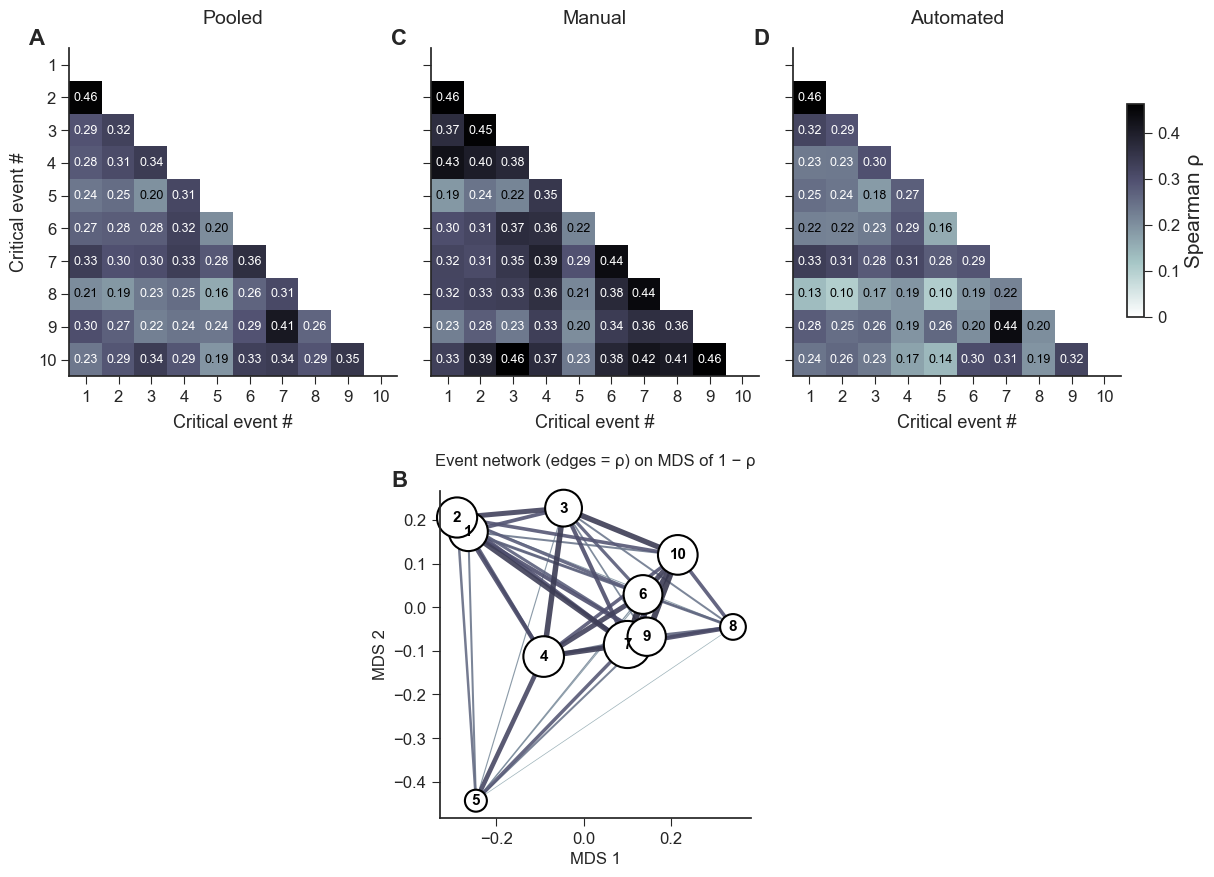

In [20]:
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FixedLocator, FixedFormatter
from matplotlib.colors import Normalize

def q_matrix_from_mantel(mt, events=EVENTS):
    """Symmetric 10x10 matrix of FDR q-values from the tidy Mantel table (diag = NaN)."""
    idx = {e: i for i, e in enumerate(events)}
    Q = np.full((len(events), len(events)), np.nan)
    for _, r in mt.iterrows():
        i, j = idx[r["event_a"]], idx[r["event_b"]]
        Q[i, j] = Q[j, i] = r["q_fdr"]
    return Q

def heatmap(ax, M, title, vmin=0, vmax=None, cmap="bone_r", annot=True, fmt="{:.2f}",
            mask_upper=True):
    """Heatmap of a symmetric event x event matrix (lower triangle only)."""
    M = np.asarray(M, dtype=float).copy()
    n = len(EVENTS)
    if mask_upper:
        M[np.triu_indices(n, k=0)] = np.nan
    if vmax is None:
        vmax = np.nanmax(M[np.tril_indices(n, k=-1)])
    cmap = plt.colormaps[cmap].copy()
    cmap.set_bad(color="white")
    im = ax.imshow(np.ma.masked_invalid(M), cmap=cmap, vmin=vmin, vmax=vmax)
    # Set x/y axis labels to numbers instead of event strings
    event_numbers = [i+1 for i in range(n)]
    ax.set_xticks(range(n)); ax.set_xticklabels(event_numbers, rotation=0, ha="center", fontsize=12)
    ax.set_yticks(range(n)); ax.set_yticklabels(event_numbers, fontsize=12)
    ax.set_title(title, fontsize=14, y=1.05)
    # Add axis labels for event numbers
    ax.set_xlabel("Critical event #", fontsize=13, labelpad=7)
    ax.set_ylabel("Critical event #", fontsize=13, labelpad=7)
    if annot:
        for i in range(n):
            for j in range(n):
                if np.isnan(M[i, j]):
                    continue
                rgba = im.cmap(im.norm(M[i, j]))
                lum = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
                ax.text(j, i, fmt.format(M[i, j]), ha="center", va="center",
                        color="white" if lum < 0.5 else "black", fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    return im

# --- Layout: A, C, D on top row; B centered on bottom ---
# Swap the C and D panels so Manual is C (middle) and Automated is D (right)
panel_hm = [("raw_pooled", "Pooled"),
            ("raw_manual", "Manual"),
            ("raw_auto",   "Automated")]
gmax = max(np.nanmax(second_order[name][np.tril_indices(len(EVENTS), k=-1)])
           for name, _ in panel_hm)

fig = plt.figure(figsize=(14, 10))
# Reduce wspace for tighter horizontal spacing between A, C, D panels
gs = GridSpec(2, 3, figure=fig, wspace=0.001, hspace=0.35,
             height_ratios=[1, 1])

ax_a = fig.add_subplot(gs[0, 0])   # left top
ax_c = fig.add_subplot(gs[0, 1])   # center top
ax_d = fig.add_subplot(gs[0, 2])   # right top
ax_b = fig.add_subplot(gs[1, 1])   # bottom center

# --- Panels A, C, D: RSA heatmaps (shared y-axis for leftmost only) ---
for idx, (ax, (name, title)) in enumerate(zip([ax_a, ax_c, ax_d], panel_hm)):
    im = heatmap(ax, second_order[name], title, vmin=0, vmax=gmax)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if idx > 0:
        ax.set_yticklabels([])
        ax.set_ylabel("")  # Only leftmost heatmap gets the 'event' y-label

# Colorbar to the right of panel D (rightmost)
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

cbax = inset_axes(ax_d, width="5%", height="65%",
                  loc='lower left', bbox_to_anchor=(1.02, 0.18, 1, 1),
                  bbox_transform=ax_d.transAxes, borderpad=0)
cb = fig.colorbar(im, cax=cbax)
# cb.ax.set_rasterized(True)
cb.set_label("Spearman ρ", fontsize=15)
cb.set_ticks([0, 0.1, 0.2, 0.3, 0.4])
cb.set_ticklabels(["0", "0.1", "0.2", "0.3", "0.4"], fontsize=12)

# --- Panel B: Event network laid out by MDS from 1 − ρ (primary RSA) ---
Mprim = second_order["raw_pooled"].copy()
Qprim = q_matrix_from_mantel(mantel_tables["raw_pooled"])
Dsim = 1.0 - Mprim
np.fill_diagonal(Dsim, 0.0)
Dsim = np.clip((Dsim + Dsim.T) / 2.0, 0, None)

n_ev = Dsim.shape[0]
J = np.eye(n_ev) - np.ones((n_ev, n_ev)) / n_ev
Bc = -0.5 * J @ (Dsim ** 2) @ J
evals, evecs = np.linalg.eigh(Bc)
order = np.argsort(evals)[::-1]
L2 = np.clip(evals[order][:2], 0, None)
emb = evecs[:, order[:2]] * np.sqrt(L2)

# Edge COLOR reuses the A/C/D colormap + scale so the shared colorbar applies here too.
edge_cmap = plt.colormaps["bone_r"]
edge_norm = Normalize(vmin=0, vmax=gmax)
iu = np.triu_indices(n_ev, 1)
# Edge WIDTH uses its own min-max normalization over the observed off-diagonal rho,
# so the full thin->thick range is used. (The color scale starts at 0, which would
# otherwise squeeze every width into the upper part of the scale and make the lines
# look uniformly thick.) LW_GAMMA > 1 exaggerates mid-range differences.
rho_off = Mprim[iu]
width_norm = Normalize(vmin=float(rho_off.min()), vmax=float(rho_off.max()))
LW_MIN, LW_MAX, LW_GAMMA = 0.5, 8.0, 1.5
# Draw weakest edges first so the strongest links sit on top.
for i, j in sorted(zip(*iu), key=lambda ij: Mprim[ij]):
    rho, q = Mprim[i, j], Qprim[i, j]
    sig = q < FDR_ALPHA
    lw = LW_MIN + (LW_MAX - LW_MIN) * width_norm(rho) ** LW_GAMMA
    ax_b.plot([emb[i, 0], emb[j, 0]], [emb[i, 1], emb[j, 1]],
              color=edge_cmap(edge_norm(rho)) if sig else "0.75",
              lw=lw,
              ls="-" if sig else "--",
              alpha=0.9 if sig else 0.5, zorder=1, solid_capstyle="round")

# Node size encodes centrality = mean ρ of an event with the other nine.
centrality = np.array([np.nanmean(np.delete(Mprim[i], i)) for i in range(n_ev)])
node_size = 250 + 900 * (centrality - centrality.min()) / np.ptp(centrality)
# clip_on=False so boundary nodes (e.g. 5, 8, 2) are never cut by the axes edge.
ax_b.scatter(emb[:, 0], emb[:, 1], s=node_size, c="white",
             edgecolors="black", linewidths=1.5, zorder=2, clip_on=False)
for i in range(n_ev):
    ax_b.annotate(str(i + 1), (emb[i, 0], emb[i, 1]), fontsize=11,
                  ha="center", va="center", fontweight="bold",
                  color="black", zorder=3, clip_on=False)

# Pad the data limits so the largest markers have room to render fully.
pad = 0.06 * max(np.ptp(emb[:, 0]), np.ptp(emb[:, 1]))
ax_b.set_xlim(emb[:, 0].min() - pad, emb[:, 0].max() + pad)
ax_b.set_ylim(emb[:, 1].min() - pad, emb[:, 1].max() + pad)

ax_b.set_title("Event network (edges = ρ) on MDS of 1 − ρ", fontsize=12, y=1.05)
ax_b.set_xlabel("MDS 1", fontsize=12)
ax_b.set_ylabel("MDS 2", fontsize=12)
ax_b.tick_params(labelsize=12)
ax_b.set_aspect("equal", adjustable="box")
ax_b.spines['top'].set_visible(False)
ax_b.spines['right'].set_visible(False)

# --- Panel labels (anchored to each column's left edge via GridSpec) ---
from matplotlib.transforms import blended_transform_factory
col_left = [gs[0, c].get_position(fig).x0 for c in range(3)]
panel_x = {ax_a: col_left[0], ax_c: col_left[1], ax_d: col_left[2], ax_b: col_left[1]}
for ax, label in zip([ax_a, ax_c, ax_d, ax_b], list("ACDB")):
    trans = blended_transform_factory(fig.transFigure, ax.transAxes)
    ax.text(panel_x[ax] - 0.005, 1.06, label, transform=trans,
            fontsize=16, fontweight="bold", va="top", ha="right")

if SAVE_OUTPUTS:
    fig.savefig(OUT_DIR / "fig_rsa_composite.pdf", dpi=600)
    fig.savefig(OUT_DIR / "fig_rsa_composite.png", dpi=600)
    fig.savefig(OUT_DIR / "fig_rsa_composite.svg", dpi=600)
plt.show()